#### Libraries

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score

#### Data Load

In [2]:
path = "/Users/etmco/MiuulDS20_Course/datasets/churn.csv"
df = pd.read_csv(path)

In [3]:
df.head(20)

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Churn
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,1
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,1
2,Eric Lozano,38.0,12884.75,0,6.67,12.0,1
3,Phillip White,42.0,8010.76,0,6.71,10.0,1
4,Cynthia Norton,37.0,9191.58,0,5.56,9.0,1
5,Jessica Williams,48.0,10356.02,0,5.12,8.0,1
6,Eric Butler,44.0,11331.58,1,5.23,11.0,1
7,Zachary Walsh,32.0,9885.12,1,6.92,9.0,1
8,Ashlee Carr,43.0,14062.60,1,5.46,11.0,1
9,Jennifer Lynch,40.0,8066.94,1,7.11,11.0,1


#### Data Control

In [4]:
df.shape

(900, 7)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Names            900 non-null    object 
 1   Age              900 non-null    float64
 2   Total_Purchase   900 non-null    float64
 3   Account_Manager  900 non-null    int64  
 4   Years            900 non-null    float64
 5   Num_Sites        900 non-null    float64
 6   Churn            900 non-null    int64  
dtypes: float64(4), int64(2), object(1)
memory usage: 49.3+ KB


In [6]:
df.iloc[:,0:5].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,900.0,41.816667,6.127560,22.0,38.0000,42.000,46.000,65.00
Total_Purchase,900.0,10062.824033,2408.644532,100.0,8497.1225,10045.870,11760.105,18026.01
Account_Manager,900.0,0.481111,0.499921,0.0,0.0000,0.000,1.000,1.00
Years,900.0,5.273156,1.274449,1.0,4.4500,5.215,6.110,9.15


In [7]:
df.isnull().sum()

Names              0
Age                0
Total_Purchase     0
Account_Manager    0
Years              0
Num_Sites          0
Churn              0
dtype: int64

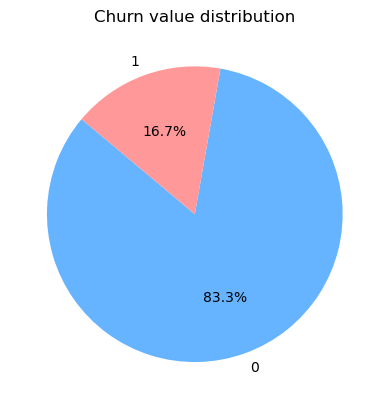

In [60]:
churn_data = df["Churn"].value_counts()
plt.pie(churn_data, labels = churn_data.index,autopct = '%1.1f%%', startangle = 140, colors = ['#66b3ff','#ff9999'])
plt.title("Churn value distribution")
plt.show()

#### Data Splitting

In [13]:
X = df.drop("Churn", axis = 1)
y = df["Churn"]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [15]:
X_train_num = X_train.select_dtypes(include=["number"])
X_test_num = X_test.select_dtypes(include=["number"])

#### Model

In [41]:
#lr = LogisticRegression()
"""
/opt/miniconda3/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
"""
lr = LogisticRegression(max_iter = 1000)
rf = RandomForestClassifier()
dummy = DummyClassifier()
lr.fit(X_train_num, y_train)
rf.fit(X_train_num, y_train)
dummy.fit(X_train_num, y_train)

DummyClassifier()

In [42]:
models = [
    ('Baseline (Most Frequent)', DummyClassifier(strategy='most_frequent')),
    ('Logistic Regression', LogisticRegression(max_iter=1000)),
    ('Random Forest', RandomForestClassifier(n_estimators=100))
]

#### Model Evaluation

In [43]:
y_pred = lr.predict(X_test_num)

In [44]:
for name, model in models:
    model.fit(X_train_num, y_train)
    score = model.score(X_test_num, y_test)
    print(f"{name} Score: {score:.4f}")

Baseline (Most Frequent) Score: 0.8222
Logistic Regression Score: 0.9000
Random Forest Score: 0.8667


In [45]:
from sklearn.metrics import classification_report

models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "Dummy Classifier": dummy
}

for name, m in models.items():
    predictions = m.predict(X_test_num)
    print(f"--- {name} Report ---")
    print(classification_report(y_test, predictions))
    print("-" * 30)

--- Logistic Regression Report ---
              precision    recall  f1-score   support

           0       0.92      0.96      0.94       148
           1       0.77      0.62      0.69        32

    accuracy                           0.90       180
   macro avg       0.85      0.79      0.82       180
weighted avg       0.89      0.90      0.90       180

------------------------------
--- Random Forest Report ---
              precision    recall  f1-score   support

           0       0.88      0.97      0.92       148
           1       0.72      0.41      0.52        32

    accuracy                           0.87       180
   macro avg       0.80      0.69      0.72       180
weighted avg       0.85      0.87      0.85       180

------------------------------
--- Dummy Classifier Report ---
              precision    recall  f1-score   support

           0       0.82      1.00      0.90       148
           1       0.00      0.00      0.00        32

    accuracy            

/opt/miniconda3/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/miniconda3/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/miniconda3/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


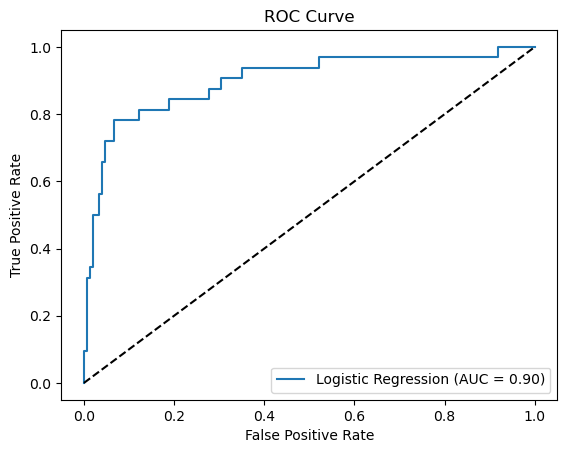

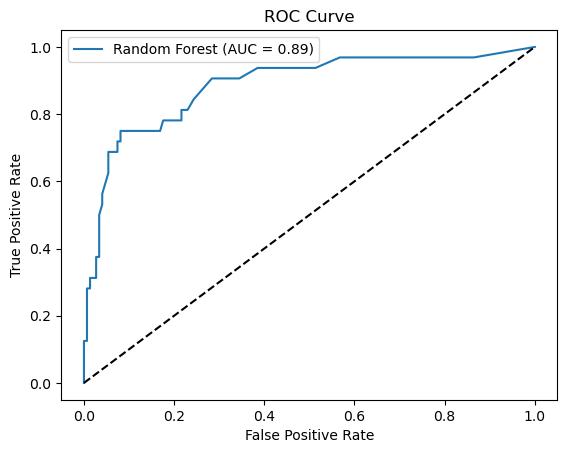

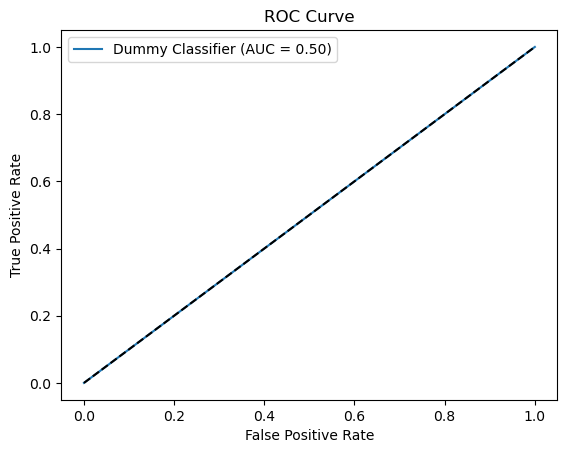

In [65]:
for name, model in models.items():
    y_probs = model.predict_proba(X_test_num)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_probs)
    auc_score = roc_auc_score(y_test, y_probs)

    # Grafiği çiz
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.2f})')
    plt.plot([0, 1], [0, 1], 'k--') # Rastgele tahmin çizgisi
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.show()